In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm08nci
interpreter: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
notebook name: 2026-06-18-multistint-complexity
notebook path: /home/runner/work/oee4/oee4/binder/2026-06-18-multistint-complexity.ipynb
revision: bdac574
timestamp: 2026-06-18T17:17:55Z00:00

IPython==7.16.1
packaging==26.0


In [4]:
teeplot_subdir = "2026-06-18-multistint-complexity"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions/stage={2 + bool(prefix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    print(len(competitions_df), "competitions to preprocess")
    print(len(control_fits_df), "control fits available")
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
prefix = ""
dfs = []
for bucket, stint in [
    ("prq49", 20),
    ("prq49", 40),
    ("prq49-20stint", 0),
    ("prq49-40stint", 0),
]:
    endeavor = {
        "prq49": 16,
        "prq49-20stint": 17,
        "prq49-40stint": 18,
    }[bucket]

    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    try:
        series_profiles, = bucket_handle.objects.filter(
            Prefix=f'endeavor={endeavor}/{prefix}variant-competitions/stage=3+what=collated/stint={stint}/',
        )
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
        control_fits_df = get_control_t_distns(bucket, prefix, endeavor, stint)
        df = pd.read_csv(
            f's3://{bucket}/{series_profiles.key}',
            compression='xz',
        )
        # df = df[df["Competition Series"] == 16005]
        # df = df.groupby([
        #     "genome variation"
        # ]).mean(numeric_only=True).reset_index()
        df["Stint"] = stint
        df["Series"] = df["Competition Series"]
        dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
        df = preprocess_competition_fitnesses(df, control_fits_df)
        assert "Series" in df.columns, df.columns

        df = df.copy()
        df["bucket"] = bucket
        df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
        dfs.append(df)
    except Exception as e:
        print(e)
        print(f"Skipping {bucket=}, {stint=}, {prefix=}")


10714 competitions to preprocess
40 control fits available
18210 competitions to preprocess
40 control fits available
6742 competitions to preprocess
40 control fits available
14408 competitions to preprocess
40 control fits available


In [8]:
df = pd.concat(dfs)


In [9]:
pd.options.display.max_columns = None


In [10]:
dfxx = df[
    df["Root ID"] == 1
].groupby(["Series", "Stint", "bucket", "variant"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "genome variation": "count",
    },
)
dfxx


Is More Fit  Is Less Fit  Is Neutral  \
Series Stint bucket        variant                                          
16000  20    prq49         wildtype           12           14         188   
       40    prq49         wildtype            2           28         385   
16001  20    prq49         wildtype            0           11          32   
       40    prq49         wildtype            6           11         211   
16002  20    prq49         wildtype            6           12         253   
...                                          ...          ...         ...   
18035  0     prq49-40stint wildtype            4           20          88   
18036  0     prq49-40stint wildtype            4           17          49   
18037  0     prq49-40stint wildtype           10           10          44   
18038  0     prq49-40stint wildtype           21            6          20   
18039  0     prq49-40stint wildtype            4           22          55   

                                     genome variation  
Series Stint bucket        variant                     
16000  20    prq49         wildtype               214  
       40    prq49         wildtype               415  
16001  20    prq49         wildtype                43  
       40    prq49         wildtype               228  
16002  20    prq49         wildtype               271  
...                                               ...  
18035  0     prq49-40stint wildtype               112  
18036  0     prq49-40stint wildtype                70  
18037  0     prq49-40stint wildtype                64  
18038  0     prq49-40stint wildtype                47  
18039  0     prq49-40stint wildtype                81  

[159 rows x 4 columns]

In [11]:
dfxx = dfxx.reset_index(drop=False)


In [12]:
dfxx["bucket-stint"] = dfxx["bucket"] + "-stint" + dfxx["Stint"].astype(str)


teeplots/col=bucket-stint+viz=relplot+x=series+y=is-more-fit+ext=.pdf
teeplots/col=bucket-stint+viz=relplot+x=series+y=is-more-fit+ext=.png


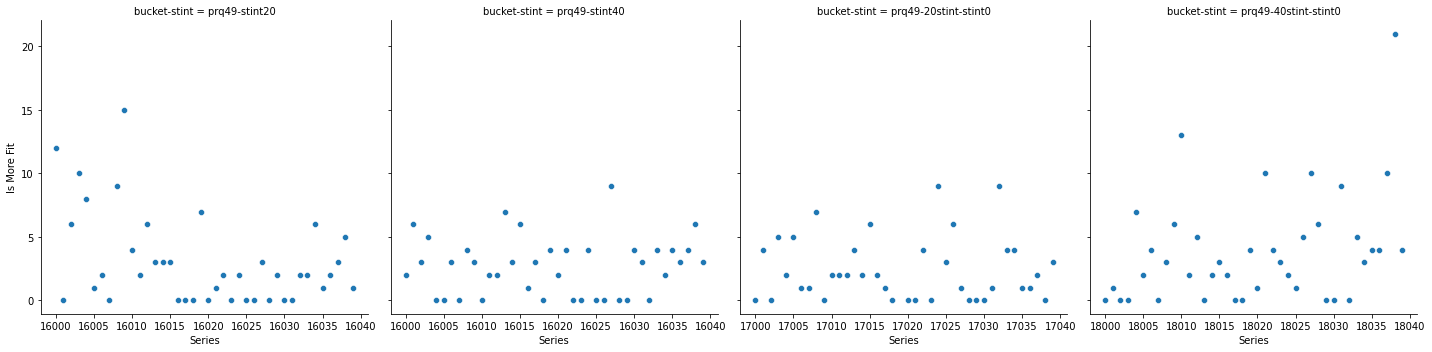

teeplots/col=bucket-stint+viz=relplot+x=series+y=is-less-fit+ext=.pdf
teeplots/col=bucket-stint+viz=relplot+x=series+y=is-less-fit+ext=.png


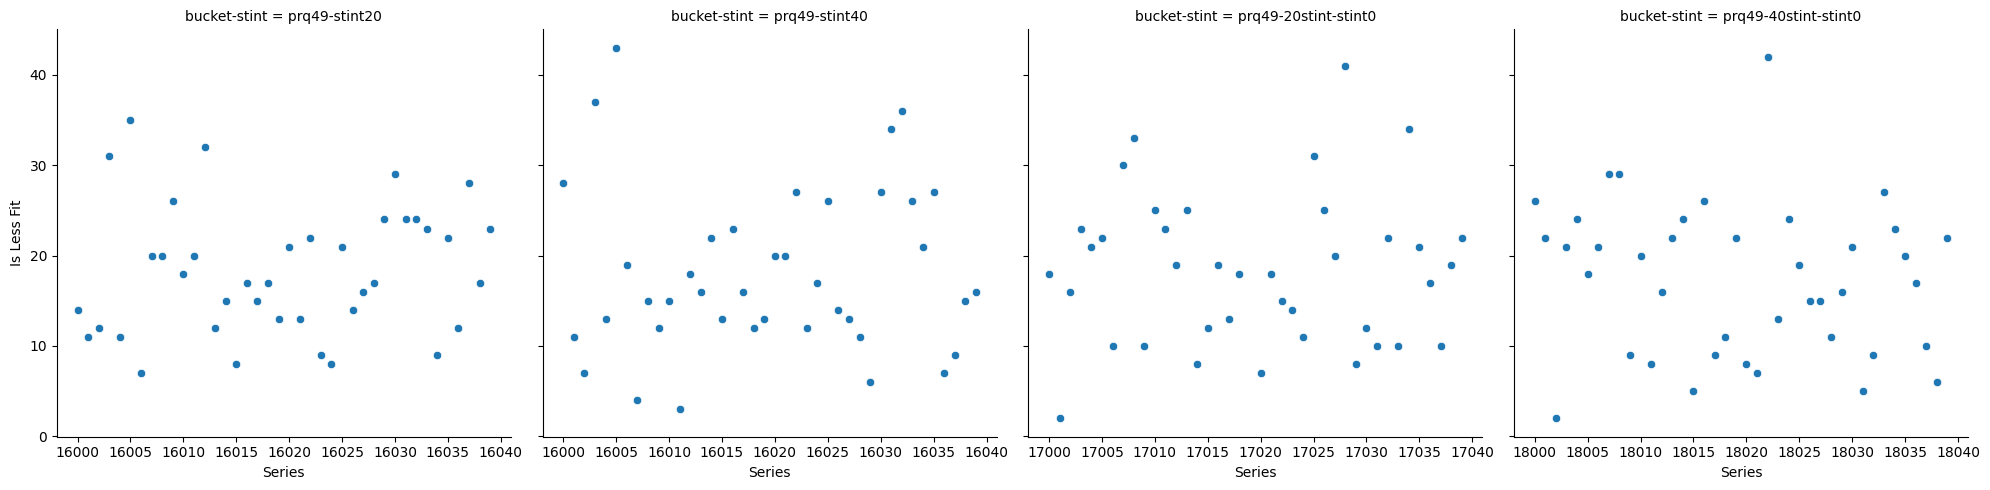

In [13]:
for y in ["Is More Fit", "Is Less Fit"]:
    with tp.teed(
        sns.relplot,
        data=dfxx,
        x="Series",
        y=y,
        col="bucket-stint",
        markers=True,
        dashes=False,
        facet_kws=dict(sharex=False),
    ) as _:
        pass


teeplots/hue=bucket-stint+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.png


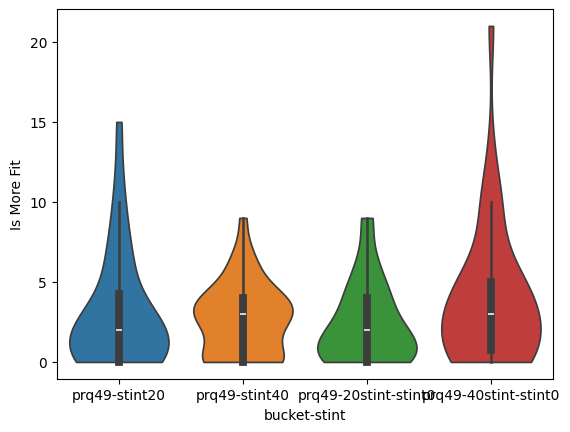

teeplots/hue=bucket-stint+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.png


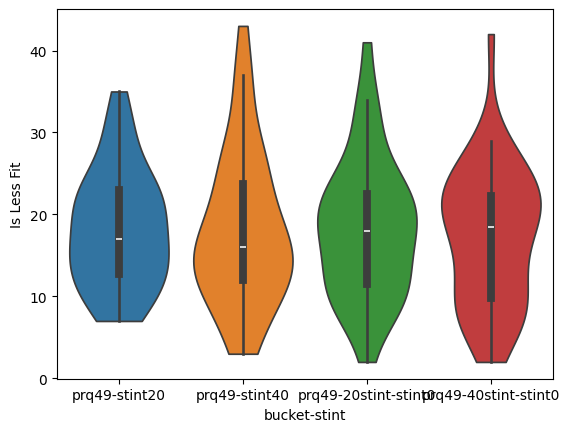

In [14]:
for y in ["Is More Fit", "Is Less Fit"]:
    with tp.teed(
        sns.violinplot,
        data=dfxx,
        y=y,
        hue="bucket-stint",
        x="bucket-stint",
        cut=0,
    ) as _:
        pass


teeplots/hue=bucket-stint+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.png


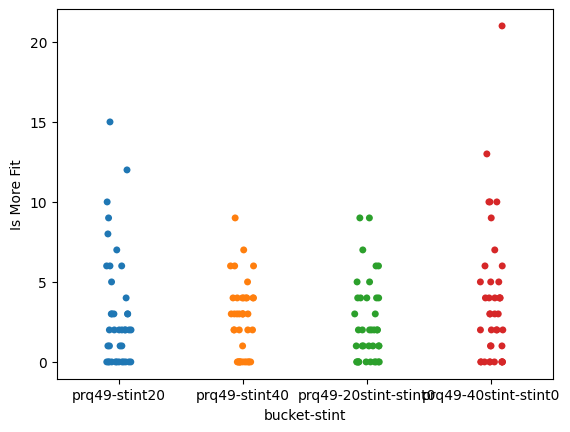

teeplots/hue=bucket-stint+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.png


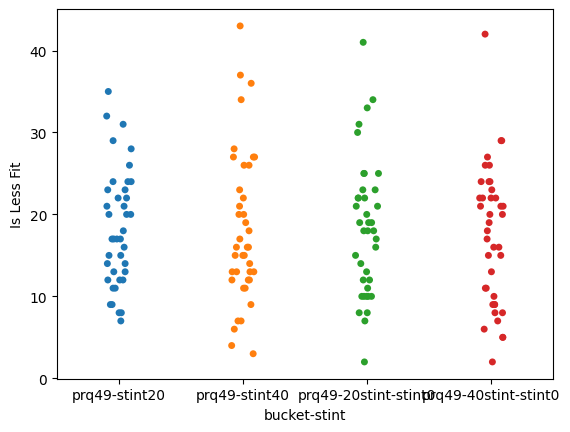

In [15]:
for y in ["Is More Fit", "Is Less Fit"]:
    with tp.teed(
        sns.stripplot,
        data=dfxx,
        y=y,
        hue="bucket-stint",
        x="bucket-stint",
    ) as _:
        pass
